In [21]:
from toolbox.cSection import makeSampleCrossSection
from toolbox.patterns import Patterns
from toolbox.periodic import PeriodicTissue
from toolbox.minimization import FIREminimization
from toolbox import stress
import matplotlib.pyplot as plt
from toolbox import stress
import os
import numpy as np
import pandas as pd
import glob
dir = "3_cells_bidisperse_0.025/"
df = pd.read_csv("{}stresses.csv".format(dir))
print(df["CellID"])
ids = [int(os.path.basename(f).split(".")[0]) for f in glob.glob("{}*.bulk.txt".format(dir))]
ids = sorted(ids)
final_iter = ids[-1]
for iter in range(final_iter+1):
    file = "{}.bulk.txt".format(iter)
    sample = PeriodicTissue.from_config(dir,file)
    min = FIREminimization.periodic_tissue(sample)
    min.load_cell_parameters("cellParameters.{}.input".format(iter))
    for i, row in df.iterrows():
        cellID = row["CellID"]
        target_stress = row["Target"]
        cell = sample.cells_[cellID]
        shear = stress.calculate_max_shear_stress(sample, cellID)
        cell.max_shear_stress_ = shear
        vtk_scalar = abs(cell.max_shear_stress_ - target_stress)/ target_stress
        for polygonID in cell.polygons_:
            polygon = sample.polygons_[polygonID]
            polygon.vtk_scalar_ = vtk_scalar
    sample.write_cell_collection_vtk(df["CellID"].to_numpy(),"{}.target_cells.vtk".format(iter),use_scalar=True)



0    183
1    277
2      7
Name: CellID, dtype: int64


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


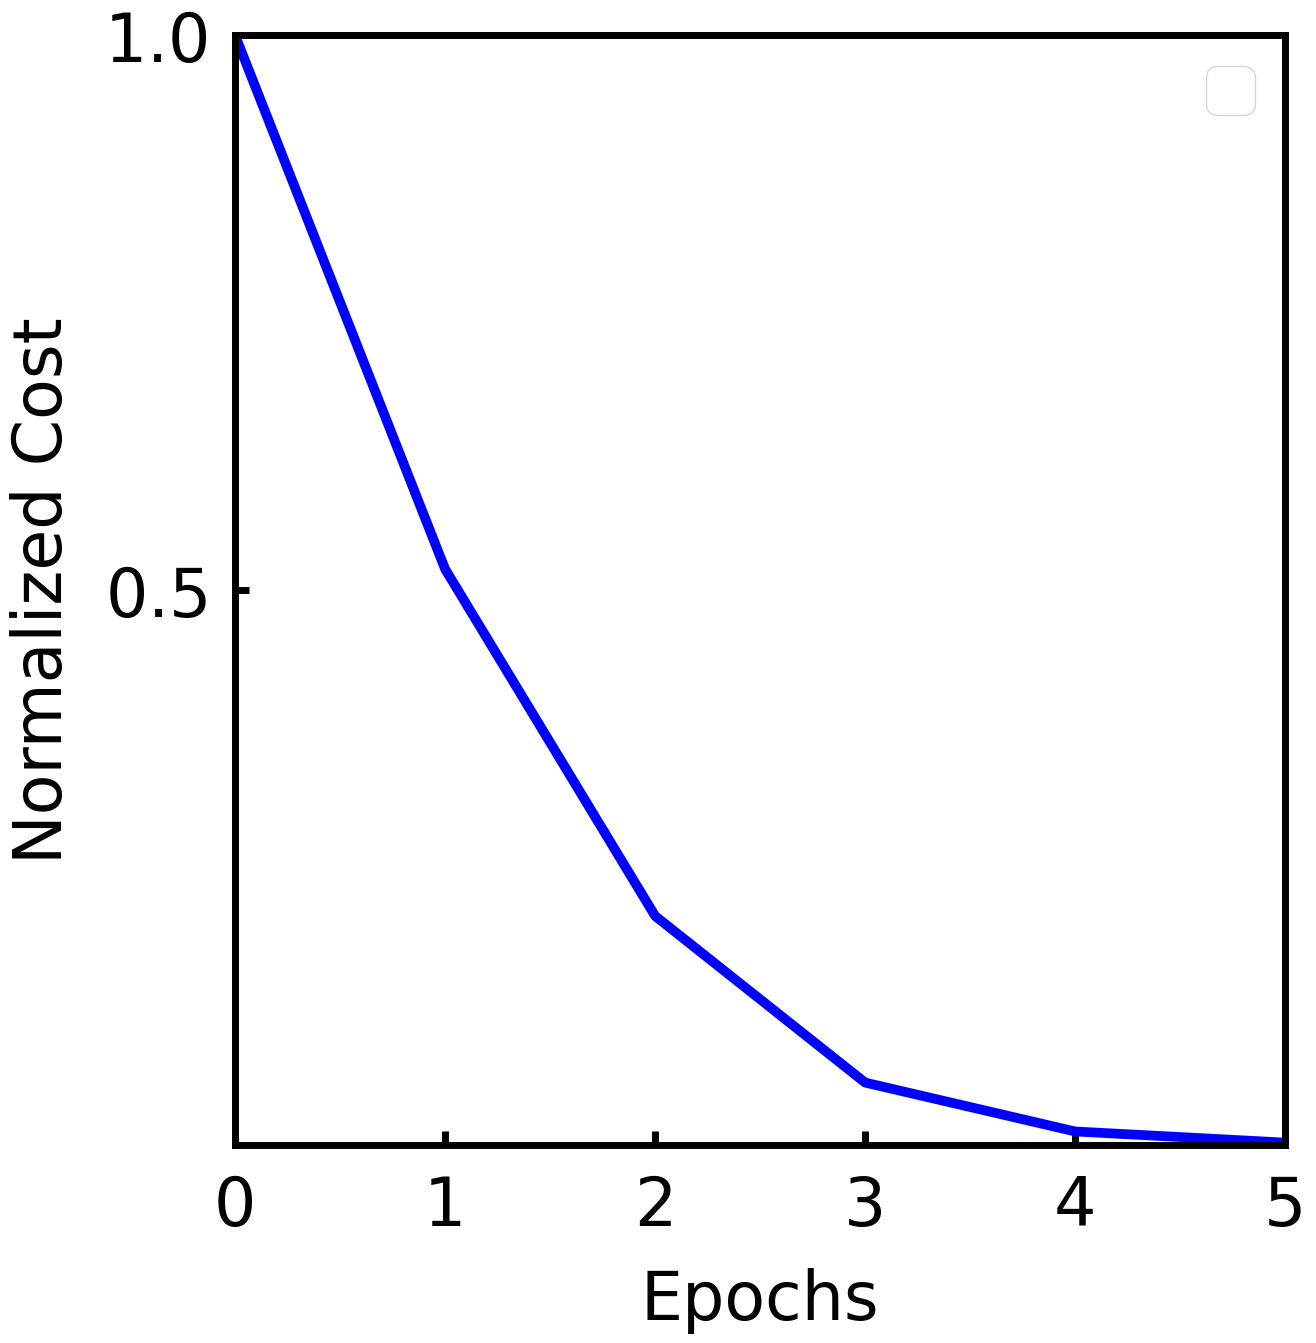

In [45]:
from toolbox import manuscriptPlots
from toolbox.periodic import PeriodicTissue
from toolbox.minimization import FIREminimization
from toolbox import stress
import pandas as pd
import numpy as np

def s0_histogram(dir, final_iter):
    plotter = manuscriptPlots.plot()
    plotter.set_ylim(0,25)
    plotter.set_xlim(4.75,5)
    plotter.set_xticks([0.25*i for i in range(150)])
    plotter.set_yticks([5*i for i in range(1,100)])
    plotter.set_xlabel(r"$s_0$")
    plotter.set_yScaled()
    plotter.initialize_figure()
    df = pd.read_csv("{}cellParameters.{}.input".format(dir,final_iter), sep=" ",header=None)
    plotter.histogram_from_dataframe(df[2],color = "blue", bins = 20, label = "_final")
    plotter.save_fig("{}/s0_histogram.png".format(dir))

def combined_stress_histogram(dir, final_iter):
    plotter = manuscriptPlots.plot()
    plotter.set_ylim(0,7.5)
    plotter.set_xlim(0,0.75)
    plotter.set_xticks([0.25*i for i in range(150)])
    plotter.set_yticks([2.5*i for i in range(1,100)])
    plotter.set_xlabel(r"$\sigma_{shear}$")
    plotter.set_yScaled()
    plotter.initialize_figure()

    #init
    file = "init_config.txt"
    sample = PeriodicTissue.from_config(dir, file)
    min = FIREminimization.periodic_tissue(sample)
    min.load_cell_parameters("cellParameters.init.input")
    stresses = []
    for cellID,cell in sample.cells_.items():
        cell.max_shear_stress_ = stress.calculate_max_shear_stress(sample,cellID)
        stresses.append(cell.max_shear_stress_)
    df = pd.DataFrame({"stress": stresses})
    plotter.histogram_from_dataframe(df["stress"],color = "red", bins = 20, label = "initial")

    #final
    file = "{}.bulk.txt".format(final_iter)
    sample = PeriodicTissue.from_config(dir, file)
    min = FIREminimization.periodic_tissue(sample)
    min.load_cell_parameters("cellParameters.{}.input".format(final_iter))
    stresses = []
    for cellID,cell in sample.cells_.items():
        cell.max_shear_stress_ = stress.calculate_max_shear_stress(sample,cellID)
        stresses.append(cell.max_shear_stress_)
    df = pd.DataFrame({"stress": stresses})
    plotter.histogram_from_dataframe(df["stress"],color = "blue", bins = 20, label = "final")
    plotter.save_fig("{}stress_histogram.png".format(dir))

def cost_plot(dir):
    plotter = manuscriptPlots.plot()
    plotter.set_ylim(0,1)
    plotter.set_xlim(0,5)
    plotter.set_xticks([1*i for i in range(150)])
    plotter.set_yticks([.5*i for i in range(1,100)])
    plotter.set_xlabel("Epochs")
    plotter.set_ylabel("Normalized Cost")
    plotter.set_yScaled()
    plotter.initialize_figure()
    array = np.loadtxt("{}costs.txt".format(dir))
    array/=array[0]
    iters = np.arange(len(array))
    plotter.plot_xy(iters, array, color = "blue", label = "_final")
    plotter.save_fig("{}/cost.png".format(dir))


dir = "3_cells_bidisperse_0.025/"
# dir = "7_bidisperse_5_4.9_0.5_decrease/"
final_iter = 5
# s0_histogram(dir, final_iter)
# combined_stress_histogram(dir, final_iter)
cost_plot(dir)


